# Recreation of Romallosa et al. (2003) Figure 2

This notebook recreates Figure 2 from:
**Romallosa, K.M., Bantang, J., Saloma, C. "Three-dimensional light distribution near the focus of a tightly focused beam of few-cycle optical pulses" Phys. Rev. A 68, 033812 (2003)**

Figure 2 shows transverse and axial intensity distributions for:
- Continuous-wave beam (750 nm)
- 1-fs optical pulse (center wavelength 750 nm)

System parameters: λc = 750 nm, NA = 0.8, n = 1.3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optical_diffraction import (
    OpticalSystem, 
    PulsedBeam,
    create_transverse_profile,
    create_axial_profile,
    create_pulsed_transverse_profile,
    create_pulsed_axial_profile
)

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## System Parameters from Romallosa Paper

In [2]:
# Romallosa paper parameters
center_wavelength = 750e-9  # 750 nm
numerical_aperture = 0.8    # NA = 0.8
refractive_index = 1.3
pulse_width = 1e-15         # 1 fs

# Create optical system
system = OpticalSystem(
    wavelength=center_wavelength,
    numerical_aperture=numerical_aperture,
    refractive_index=refractive_index,
    name="Romallosa system (750nm, NA=0.8, n=1.3)"
)

print(system.summary())

Optical System: Romallosa system (750nm, NA=0.8, n=1.3)
Vacuum Wavelength:   750.0 nm
Medium Wavelength:   576.9 nm
Numerical Aperture:  0.800
Refractive Index:    1.300
Angular Aperture:    38.0°
Wave Number (k):     10890854.53 rad/m

Derived Properties:
Diffraction Limit:   367.8 nm
Airy Radius:         439.9 nm
Rayleigh Length:     2.83 μm
Min Beam Waist:      229.6 nm



## Create 1-fs Pulsed Beam

From the paper: "The spectral bandwidth of a 1-fs pulse (λc = 750 nm) is Δνc ≈ 4.4×10^14 Hz. In wavelength units, the spectral band spans from 483 nm to 1.67 μm."

In [3]:
# Create 1-fs pulsed beam
pulsed_beam = PulsedBeam(
    center_wavelength=center_wavelength,
    pulse_width_fwhm=pulse_width,
    chirp_parameter=0.0,  # Unchirped pulse
    time_bandwidth_product=0.44  # Gaussian pulse
)

# Use automatic spectral range calculation (no override)
# This should give similar results to the paper's range of 483 nm to 1.67 μm

print(pulsed_beam.summary())

Pulsed Beam Parameters:
Center wavelength: 750.0 nm
Pulse width (FWHM): 1.0 fs
Spectral bandwidth: 440.00 THz
Integration range: 484 nm to 1.67 μm
Coherence length: 299.8 nm
Nyquist limit (λ/2): 375.0 nm
Few-cycle pulse: Yes



## Generate Spectral Profile

Show the spectral distribution of the 1-fs pulse

0.000521498436428288


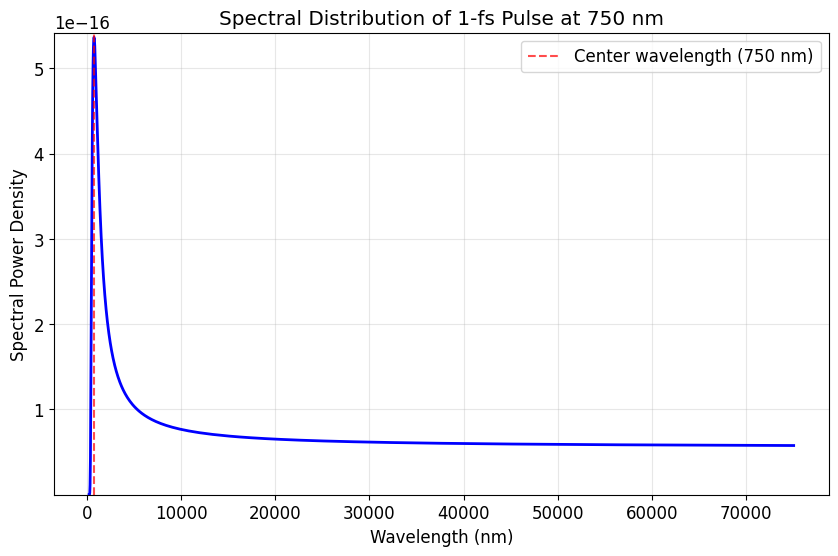

Spectral range: 227 nm to 75052 nm
Center wavelength: 750 nm
Spectral bandwidth: 440.00 THz


In [4]:
# Generate frequency array for spectral plot
nu_min, nu_max = pulsed_beam.get_spectral_range(3)
frequencies = np.linspace(nu_min, nu_max, 1000)
wavelengths = (3e8 / frequencies) * 1e9  # Convert to nm

# Calculate spectral distribution
spectral_power = pulsed_beam.spectral_distribution(frequencies)

# Plot spectral profile
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, spectral_power, 'b-', linewidth=2)
plt.axvline(750, color='r', linestyle='--', alpha=0.7, label='Center wavelength (750 nm)')
# plt.axvline(483, color='g', linestyle='--', alpha=0.7, label='Spectral range limits')
# plt.axvline(1670, color='g', linestyle='--', alpha=0.7)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral Power Density')
plt.title('Spectral Distribution of 1-fs Pulse at 750 nm')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.xlim(483, 1670)
plt.ylim(np.min(spectral_power), np.max(spectral_power)*1.01)
print(np.min(spectral_power)/np.max(spectral_power)*100)
plt.show()

print(f"Spectral range: {wavelengths[-1]:.0f} nm to {wavelengths[0]:.0f} nm")
print(f"Center wavelength: {center_wavelength*1e9:.0f} nm")
print(f"Spectral bandwidth: {pulsed_beam.delta_nu*1e-12:.2f} THz")

0.000521498436428288


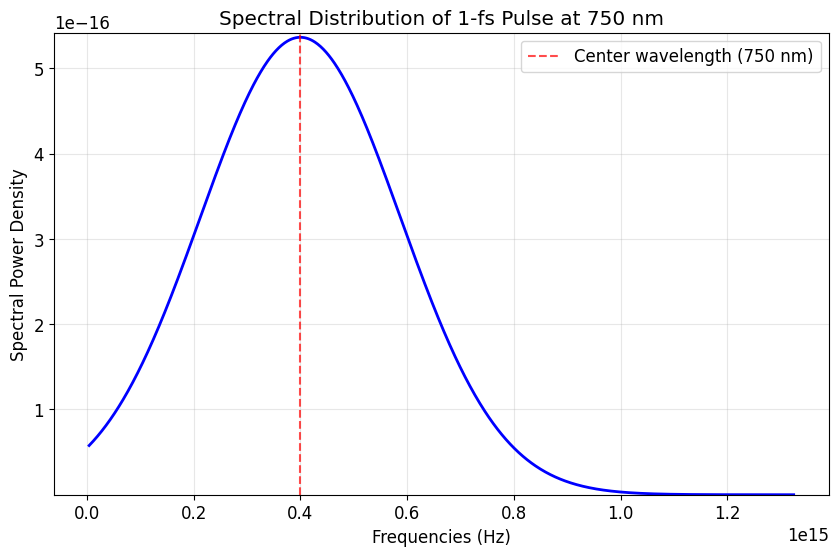

Spectral range: 227 nm to 75052 nm
Center wavelength: 750 nm
Spectral bandwidth: 440.00 THz


In [5]:
# Generate frequency array for spectral plot
nu_min, nu_max = pulsed_beam.get_spectral_range(3)
frequencies = np.linspace(nu_min, nu_max, 1000)
wavelengths = (3e8 / frequencies) * 1e9  # Convert to nm

# Calculate spectral distribution
spectral_power = pulsed_beam.spectral_distribution(frequencies)

# Plot spectral profile
plt.figure(figsize=(10, 6))
plt.plot(frequencies, spectral_power, 'b-', linewidth=2)
plt.axvline(3e8/750e-9, color='r', linestyle='--', alpha=0.7, label='Center wavelength (750 nm)')
# plt.axvline(483, color='g', linestyle='--', alpha=0.7, label='Spectral range limits')
# plt.axvline(1670, color='g', linestyle='--', alpha=0.7)
plt.xlabel('Frequencies (Hz)')
plt.ylabel('Spectral Power Density')
plt.title('Spectral Distribution of 1-fs Pulse at 750 nm')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.xlim(483, 1670)
plt.ylim(np.min(spectral_power), np.max(spectral_power)*1.01)
print(np.min(spectral_power)/np.max(spectral_power)*100)
plt.show()

print(f"Spectral range: {wavelengths[-1]:.0f} nm to {wavelengths[0]:.0f} nm")
print(f"Center wavelength: {center_wavelength*1e9:.0f} nm")
print(f"Spectral bandwidth: {pulsed_beam.delta_nu*1e-12:.2f} THz")

In [ ]:
system = OpticalSystem(
    wavelength=center_wavelength,
    numerical_aperture=numerical_aperture,
    refractive_index=refractive_index,
    name="Romallosa system (750nm, NA=0.8, n=1.3)"
)

r_range = 1e-6  # 5 μm radial range
nr_points = 1001

# Calculate CW transverse profile at focus (z=0)
print("Calculating CW transverse profile...")
r_coords, Ex_cw, Ey_cw, Ez_cw = create_transverse_profile(
    system, 
    r_range=r_range,
    nr=nr_points,
    z_constant=0.0,  # At focus
    method='vector'  # Richards-Wolf vector diffraction
)

# Calculate total intensity for CW
I_cw_transverse = np.abs(Ex_cw)**2 + np.abs(Ey_cw)**2 + np.abs(Ez_cw)**2
I_cw_transverse /= np.max(I_cw_transverse)  # Normalize

Calculating CW transverse profile...


Computing I2 integral: 100%|██████████| 1001/1001 [00:01<00:00, 908.14it/s]


(0.0, 0.15121176102206216)

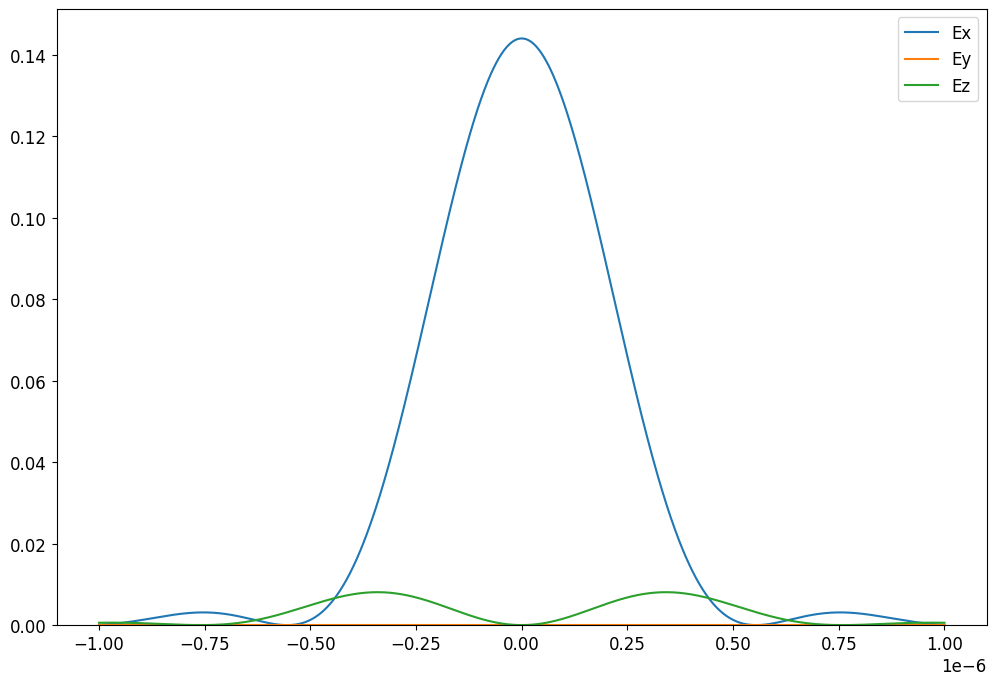

In [20]:
plt.plot(r_coords, np.abs(Ex_cw)**2, label="Ex")
plt.plot(r_coords, np.abs(Ey_cw)**2, label="Ey")
plt.plot(r_coords, np.abs(Ez_cw)**2, label="Ez")
plt.legend()
plt.ylim(bottom=0)

(0.0, 1.0497685616929102)

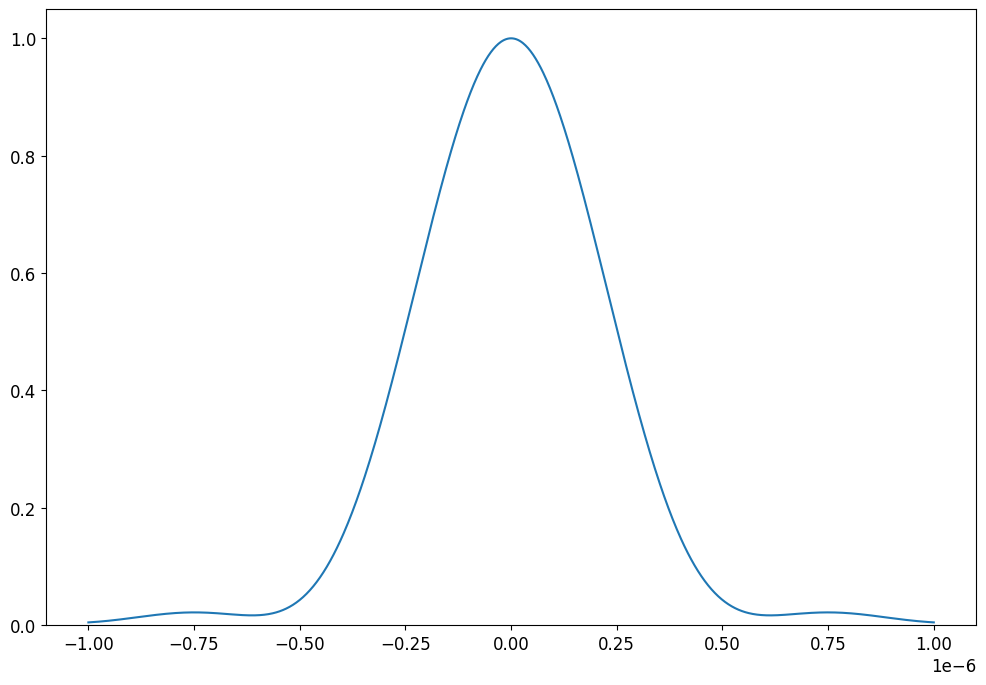

In [19]:
plt.plot(r_coords,I_cw_transverse)
plt.ylim(bottom=0)

## Calculate Transverse Profiles

Calculate transverse intensity distributions at the focus (z=0) for both CW and pulsed beams

In [ ]:
# Coordinate ranges (similar to paper's scale)
r_range = 10e-6  # 5 μm radial range
nr_points = 1001

# Calculate CW transverse profile at focus (z=0)
print("Calculating CW transverse profile...")
r_coords, Ex_cw, Ey_cw, Ez_cw = create_transverse_profile(
    system, 
    r_range=r_range,
    nr=nr_points,
    z_constant=0.0,  # At focus
    method='vector'  # Richards-Wolf vector diffraction
)

# Calculate total intensity for CW
I_cw_transverse = np.abs(Ex_cw)**2 + np.abs(Ey_cw)**2 + np.abs(Ez_cw)**2
I_cw_transverse /= np.max(I_cw_transverse)  # Normalize

# Calculate pulsed transverse profile at focus (z=0)
print("Calculating pulsed transverse profile...")
r_coords_pulsed, Ex_pulsed, Ey_pulsed, Ez_pulsed = create_pulsed_transverse_profile(
    system,
    pulsed_beam,
    r_range=r_range,
    nr=nr_points,
    z_constant=0.0,  # At focus
    n_frequencies=201,
    addition_method='incoherent' 
)

# Calculate total intensity for pulsed beam
I_pulsed_transverse = np.abs(Ex_pulsed)**2 + np.abs(Ey_pulsed)**2 + np.abs(Ez_pulsed)**2
I_pulsed_transverse /= np.max(I_pulsed_transverse)  # Normalize

print("Transverse profiles calculated.")

Calculating CW transverse profile...


Computing I2 integral: 100%|██████████| 1001/1001 [00:01<00:00, 761.06it/s]

Calculating pulsed transverse profile...



Computing I2 integral:  16%|█▌        | 156/1001 [00:06<00:24, 34.54it/s]Process SpawnProcess-30:272:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/homebrew/Caskroom/miniforge/base/envs/misc/lib/python3.8/multiprocessing/spawn.py", line 112, in spawn_main
Process SpawnProcess-27:292:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/homebrew/Caskroom/miniforge/base/envs/misc/lib/python3.8/multiprocessing/spawn.py", line 116, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    exitcode = _main(fd, parent_sentinel)
  File "/opt/homebrew/Caskroom/miniforge/base/envs/misc/lib/python3.8/multiprocessing/spawn.py", line 126, in _main
  File "<frozen importlib._bootstrap>", line 991, in _find_and_load
    self = reduction.pickle.load(from_parent)
  File "/opt/homebrew/Caskroom/miniforge/base/envs/misc/lib/python3.8/concurrent/futures/__init__.py", line 8, in <module>
  File "<

In [7]:
# Axial coordinate range
z_range = 10e-6  # ±5 μm axial range
nz_points = nr_points

# Calculate CW axial profile on-axis (r=0)
print("Calculating CW axial profile...")
z_coords, Ex_cw_ax, Ey_cw_ax, Ez_cw_ax = create_axial_profile(
    system,
    z_range=z_range,
    nz=nz_points,
    r_constant=0.0,  # On-axis
    method='vector'  # Richards-Wolf vector diffraction
)

# Calculate total intensity for CW
I_cw_axial = np.abs(Ex_cw_ax)**2 + np.abs(Ey_cw_ax)**2 + np.abs(Ez_cw_ax)**2
I_cw_axial /= np.max(I_cw_axial)  # Normalize

# Calculate pulsed axial profile on-axis (r=0)
print("Calculating pulsed axial profile...")
z_coords_pulsed, Ex_pulsed_ax, Ey_pulsed_ax, Ez_pulsed_ax = create_pulsed_axial_profile(
    system,
    pulsed_beam,
    z_range=z_range,
    nz=nz_points,
    r_constant=0.0,  # On-axis
    n_frequencies=201,
    addition_method='incoherent'  # Coherent addition
)

# Calculate total intensity for pulsed beam
I_pulsed_axial = np.abs(Ex_pulsed_ax)**2 + np.abs(Ey_pulsed_ax)**2 + np.abs(Ez_pulsed_ax)**2
I_pulsed_axial /= np.max(I_pulsed_axial)  # Normalize

print("Axial profiles calculated.")

Calculating CW axial profile...


Computing I2 integral: 100%|██████████| 2001/2001 [00:01<00:00, 1721.66it/s]

Calculating pulsed axial profile...



Computing frequency components: 100%|██████████| 201/201 [18:04<00:00,  5.40s/it]

Axial profiles calculated.


In [ ]:
# Convert and save in one step
np.savez_compressed('fig2.npz', 
                   # CW fields
                   Ex_cw_ax=np.array(Ex_cw_ax),
                   Ey_cw_ax=np.array(Ey_cw_ax),
                   Ez_cw_ax=np.array(Ez_cw_ax),
                   Ex_pulsed_ax=np.array(Ex_pulsed_ax),
                   Ey_pulsed_ax=np.array(Ey_pulsed_ax),
                   Ez_pulsed_ax=np.array(Ez_pulsed_ax),

                   


                   Ex_cw=np.array(Ex_cw), 
                   Ey_cw=np.array(Ey_cw), 
                   Ez_cw=np.array(Ez_cw),
                   I_cw=np.array(I_cw),
                   # Pulsed fields
                   Ex_pulsed=np.array(Ex_pulsed),
                   Ey_pulsed=np.array(Ey_pulsed),
                   Ez_pulsed=np.array(Ez_pulsed),
                   # Coordinate grids
                   z_coords = np.array(z_coords), 
                   r_coords = np.array(r_coords),
z_coords, Ex_cw_ax, Ey_cw_ax, Ez_cw_ax

)

## Plot Figure 2: Transverse and Axial Intensity Distributions

Recreate Figure 2 from Romallosa et al. (2003)

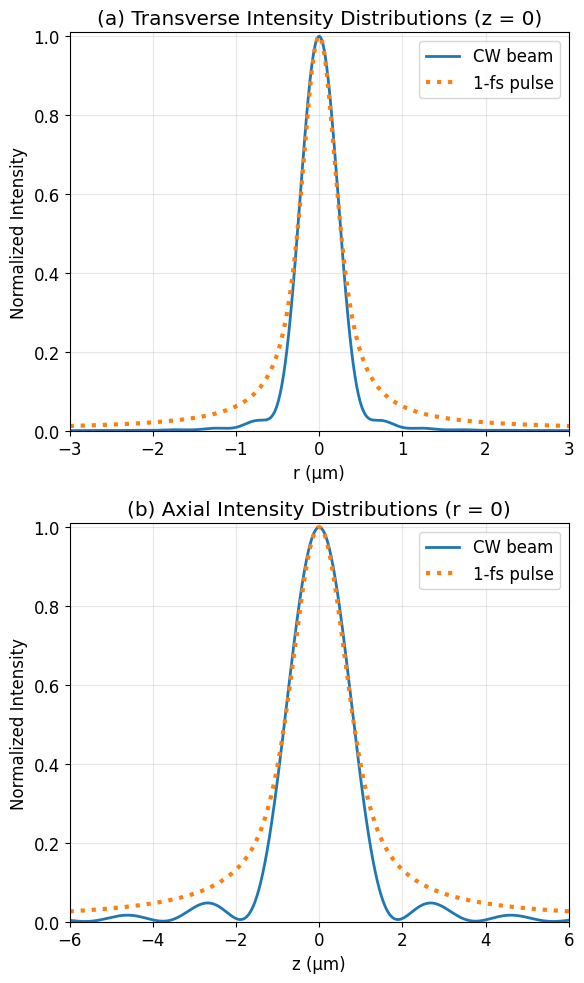

In [8]:
# Create figure with subplots matching paper layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10))

# Plot (a): Transverse intensity distributions
ax1.plot(r_coords * 1e6, I_cw_transverse, color="tab:blue", linewidth=2, label='CW beam')
ax1.plot(r_coords_pulsed * 1e6, I_pulsed_transverse, linestyle=":", color="tab:orange", linewidth=3, label='1-fs pulse')
ax1.set_xlabel('r (μm)')
ax1.set_ylabel('Normalized Intensity')
ax1.set_title('(a) Transverse Intensity Distributions (z = 0)')
ax1.legend()
ax1.grid(True, alpha=0.3)
# ax1.set_xlim(-5, 5)
ax1.set_ylim(0, 1.01)
ax1.set_xlim(-3,3)

# Plot (b): Axial intensity distributions
ax2.plot(z_coords * 1e6, I_cw_axial, color="tab:blue", linewidth=2, label='CW beam')
ax2.plot(z_coords_pulsed * 1e6, I_pulsed_axial, linestyle=':', color="tab:orange", linewidth=3, label='1-fs pulse')
ax2.set_xlabel('z (μm)')
ax2.set_ylabel('Normalized Intensity')
ax2.set_title('(b) Axial Intensity Distributions (r = 0)')
ax2.legend()
ax2.grid(True, alpha=0.3)
# ax2.set_xlim(-5, 5)
ax2.set_ylim(0, 1.01)
ax2.set_xlim(-6,6)

plt.tight_layout()
# plt.suptitle('Figure 2: Intensity Distributions (750 nm, NA = 0.8, n = 1.3)', 
            #  fontsize=14, y=0.98)
plt.show()

In [22]:
from optical_diffraction import convert_to_optical_coordinates

u_cw, v_cw = convert_to_optical_coordinates(system, r_coords, z_coords)

u_pulsed, v_pulsed = convert_to_optical_coordinates(system, r_coords_pulsed, z_coords_pulsed)

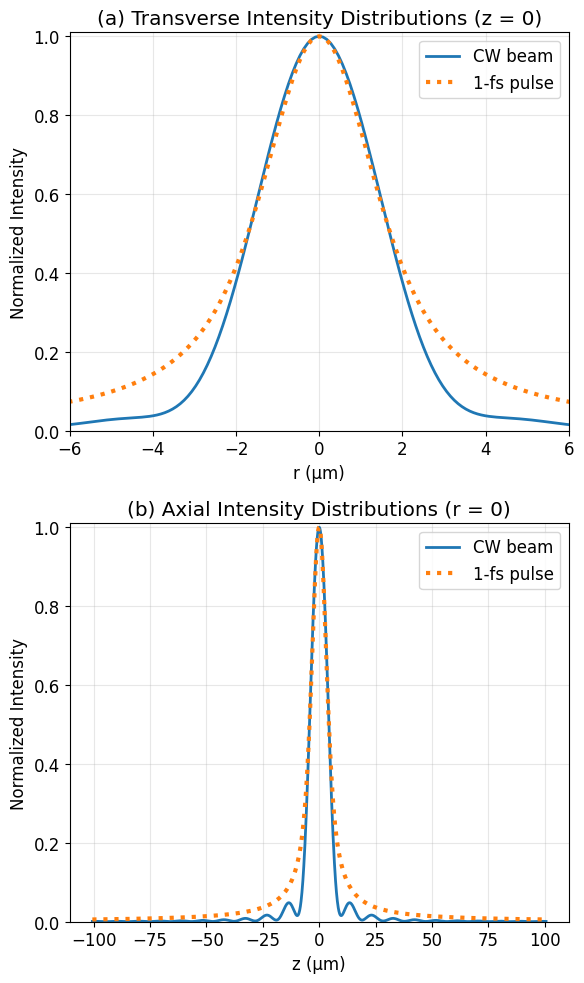

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10))
# Plot (a): Transverse intensity distributions

ax1.plot(u_cw, I_cw_transverse, color="tab:blue", linewidth=2, label='CW beam')
ax1.plot(u_cw, I_pulsed_transverse, linestyle=":", color="tab:orange", linewidth=3, label='1-fs pulse')
ax1.set_xlabel('r (μm)')
ax1.set_ylabel('Normalized Intensity')
ax1.set_title('(a) Transverse Intensity Distributions (z = 0)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-6,6)
ax1.set_ylim(0, 1.01)
# ax1.set_xlim(-1,1)

# Plot (b): Axial intensity distributions
ax2.plot(v_cw, I_cw_axial, color="tab:blue", linewidth=2, label='CW beam')
ax2.plot(v_pulsed, I_pulsed_axial, linestyle=':', color="tab:orange", linewidth=3, label='1-fs pulse')
ax2.set_xlabel('z (μm)')
ax2.set_ylabel('Normalized Intensity')
ax2.set_title('(b) Axial Intensity Distributions (r = 0)')
ax2.legend()
ax2.grid(True, alpha=0.3)
# ax2.set_xlim(-5, 5)
ax2.set_ylim(0, 1.01)
# ax2.set_xlim(-3,3)

plt.tight_layout()
# plt.suptitle('Figure 2: Intensity Distributions (750 nm, NA = 0.8, n = 1.3)', 
            #  fontsize=14, y=0.98)
plt.show()


## Analysis and Observations

Key observations matching the paper:

In [8]:
# Calculate some key metrics
print("=== Analysis of Results ===")
print(f"System parameters:")
print(f"  Center wavelength: {center_wavelength*1e9:.0f} nm")
print(f"  Numerical aperture: {numerical_aperture:.1f}")
print(f"  Refractive index: {refractive_index:.1f}")
print(f"  Pulse width: {pulse_width*1e15:.0f} fs")
print()

# Derived parameters
print(f"Derived parameters:")
print(f"  Diffraction limit: {system.diffraction_limit*1e9:.0f} nm")
print(f"  Airy radius: {system.airy_radius*1e9:.0f} nm")
print(f"  Rayleigh length: {system.rayleigh_length*1e6:.2f} μm")
print(f"  Coherence length: {pulsed_beam.coherence_length()*1e9:.0f} nm")
print()

# Find FWHM of transverse profiles
def find_fwhm_index(intensity_profile):
    """Find indices where intensity drops to half maximum"""
    half_max = np.max(intensity_profile) / 2
    indices = np.where(intensity_profile >= half_max)[0]
    if len(indices) > 0:
        return indices[0], indices[-1]
    return None, None

# Transverse FWHM
idx_start, idx_end = find_fwhm_index(I_cw_transverse)
if idx_start is not None:
    fwhm_cw_trans = (r_coords[idx_end] - r_coords[idx_start]) * 1e9
    print(f"CW transverse FWHM: {fwhm_cw_trans:.0f} nm")

idx_start, idx_end = find_fwhm_index(I_pulsed_transverse)
if idx_start is not None:
    fwhm_pulsed_trans = (r_coords_pulsed[idx_end] - r_coords_pulsed[idx_start]) * 1e9
    print(f"Pulsed transverse FWHM: {fwhm_pulsed_trans:.0f} nm")

print()
print("Key observations from Figure 2:")
print("• The 1-fs pulsed beam produces broader intensity distributions")
print("• Transverse profile: pulsed beam has no zero points (filled-in Airy pattern)")
print("• Axial profile: pulsed beam shows reduced oscillations compared to CW")
print("• These effects are due to the broad spectral content of the ultrashort pulse")

=== Analysis of Results ===
System parameters:
  Center wavelength: 750 nm
  Numerical aperture: 1.2
  Refractive index: 1.3
  Pulse width: 1 fs

Derived parameters:
  Diffraction limit: 319 nm
  Airy radius: 381 nm
  Rayleigh length: 1.64 μm
  Coherence length: 300 nm

CW transverse FWHM: 360 nm
Pulsed transverse FWHM: 480 nm

Key observations from Figure 2:
• The 1-fs pulsed beam produces broader intensity distributions
• Transverse profile: pulsed beam has no zero points (filled-in Airy pattern)
• Axial profile: pulsed beam shows reduced oscillations compared to CW
• These effects are due to the broad spectral content of the ultrashort pulse


In [9]:
np.sum(I_pulsed_transverse[I_pulsed_transverse>=0.5])/ np.sum(I_pulsed_transverse)

0.707395128637306

In [10]:
np.sum(I_pulsed_axial[I_pulsed_axial>=0.5])/ np.sum(I_pulsed_axial)

0.6646795633361902

old

In [11]:
np.sum(I_pulsed_transverse[I_pulsed_transverse>=0.5])/ np.sum(I_pulsed_transverse)

0.707395128637306

In [12]:
np.sum(I_pulsed_axial[I_pulsed_axial>=0.5])/ np.sum(I_pulsed_axial)

0.6646795633361902

In [49]:
# Convert and save in one step with automatic numpy array conversion
np.savez_compressed('fig2.npz', 
                   # Radial CW data
                   r_coords=np.array(r_coords),
                   Ex_cw=np.array(Ex_cw), 
                   Ey_cw=np.array(Ey_cw), 
                   Ez_cw=np.array(Ez_cw),
                   # Radial pulsed data
                   r_coords_pulsed=np.array(r_coords_pulsed),
                   Ex_pulsed=np.array(Ex_pulsed),
                   Ey_pulsed=np.array(Ey_pulsed),
                   Ez_pulsed=np.array(Ez_pulsed),
                   # Axial CW data
                   z_coords=np.array(z_coords),
                   Ex_cw_ax=np.array(Ex_cw_ax),
                   Ey_cw_ax=np.array(Ey_cw_ax),
                   Ez_cw_ax=np.array(Ez_cw_ax),
                   # Axial pulsed data
                   z_coords_pulsed=np.array(z_coords_pulsed),
                   Ex_pulsed_ax=np.array(Ex_pulsed_ax),
                   Ey_pulsed_ax=np.array(Ey_pulsed_ax),
                   Ez_pulsed_ax=np.array(Ez_pulsed_ax))

print("Saved fig2 data to fig2.npz")

Saved fig2 data to fig2.npz


In [50]:
fig2_data = np.load('fig2.npz')

In [52]:
fig2_data["r_coords"]

array([-1.00e-05, -9.99e-06, -9.98e-06, ...,  9.98e-06,  9.99e-06,
        1.00e-05])

In [53]:
r_coords

array([-1.00e-05, -9.99e-06, -9.98e-06, ...,  9.98e-06,  9.99e-06,
        1.00e-05])